# Model Training — Maternal Health Risk

This notebook trains and evaluates a classifier predicting maternal health risk level (low, mid, or high) from the cleaned, feature-engineered dataset. It picks up directly from the findings in `eda.ipynb`, which identified blood sugar, blood pressure, hypertension status, and age as the features most likely to carry predictive signal, and heart rate as the weakest.

The baseline model is logistic regression. Since there are three risk categories rather than two, and they aren't perfectly balanced (see EDA), evaluation will look at how well the model performs on each individual category, not just one overall accuracy number.

In [72]:
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
import shap


/Users/anastasiamistreanu/maternal-health-risk-classifier/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
conn = sqlite3.connect("../data/maternal_health_risk.db")
df = pd.read_sql_query("SELECT * FROM maternal_health_risk", conn)

In [20]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,HasHypertension,AgeBracket
0,25,130,80,15.0,98.0,86,high risk,50,0,reproductive_age
1,35,140,90,13.0,98.0,70,high risk,50,1,advanced_maternal_age
2,29,90,70,8.0,100.0,80,high risk,20,0,reproductive_age
3,30,140,85,7.0,98.0,70,high risk,55,1,reproductive_age
4,35,120,60,6.1,98.0,76,low risk,60,0,advanced_maternal_age


In [21]:
df.shape

(1012, 10)

## Preparing the Data

Splitting the dataset into features (X) and target (y), and preparing the target for scikit-learn.

In [30]:
X = df.drop(columns=["RiskLevel"])
y = df["RiskLevel"]

X = pd.get_dummies(X, columns=["AgeBracket"])

In [31]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print(encoder.classes_)

['high risk' 'low risk' 'mid risk']


In [32]:
X.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'PulsePressure', 'HasHypertension', 'AgeBracket_advanced_maternal_age',
       'AgeBracket_reproductive_age', 'AgeBracket_teen'],
      dtype='str')

In [33]:
X.dtypes

Age                                   int64
SystolicBP                            int64
DiastolicBP                           int64
BS                                  float64
BodyTemp                            float64
HeartRate                             int64
PulsePressure                         int64
HasHypertension                       int64
AgeBracket_advanced_maternal_age       bool
AgeBracket_reproductive_age            bool
AgeBracket_teen                        bool
dtype: object

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [35]:
X_train.shape

(809, 11)

In [36]:
X_test.shape

(203, 11)

## Feature Scaling and Model Training

Scaling features with StandardScaler before training, since logistic regression's optimizer converges more reliably when features share a comparable scale.

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## Model Training

Training a multinomial logistic regression to predict RiskLevel (low/mid/high) from the scaled features.

In [38]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## Prediction and Confusion Matrix

The logistic regression model was trained on the scaled training data and then used to predict the `RiskLevel` for the unseen test set. Model performance was evaluated using a confusion matrix and a classification report, allowing performance to be assessed separately for each risk category rather than relying on accuracy alone.

Because `RiskLevel` was encoded using `LabelEncoder`, the class order is determined by `encoder.classes_`:

- `0` = high risk
- `1` = low risk
- `2` = mid risk

Therefore, the rows and columns of the confusion matrix follow the order **high risk, low risk, mid risk**.

In [43]:
y_pred = model.predict(X_test_scaled)
print("Class order:", encoder.classes_)

Class order: ['high risk' 'low risk' 'mid risk']


In [44]:
print(confusion_matrix(y_test, y_pred))

[[41  4 10]
 [ 5 58 18]
 [ 6 37 24]]


In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77        55
           1       0.59      0.72      0.64        81
           2       0.46      0.36      0.40        67

    accuracy                           0.61       203
   macro avg       0.61      0.61      0.60       203
weighted avg       0.60      0.61      0.60       203



## Baseline Model Results

The baseline logistic regression model achieved an overall accuracy of **61%** on the test set.

Performance varied substantially across the three risk categories. The model performed best for **high-risk patients**, with a precision of 0.79, recall of 0.75, and F1-score of 0.77.

Performance for **low-risk patients** was moderate, with a precision of 0.59, recall of 0.72, and F1-score of 0.64.

The model performed weakest for **mid-risk patients**, with a precision of 0.46, recall of 0.36, and F1-score of 0.40. The confusion matrix shows that 37 of the 67 actual mid-risk patients were classified as low risk, indicating difficulty distinguishing between these two categories.

Because performance differs across classes, accuracy alone is insufficient to assess this model. Macro-averaged precision, recall, and F1-score provide a more balanced assessment of performance across the three risk categories.

## Class-Weighted Logistic Regression

The baseline model showed substantially poorer performance for the mid-risk class. A class-weighted logistic regression model will therefore be evaluated to determine whether giving greater weight to the less frequent classes improves per-class performance.

The `balanced` setting automatically adjusts class weights inversely according to class frequencies in the training data. Performance will be compared with the baseline model using accuracy, macro-averaged metrics, and class-specific precision, recall, and F1-scores.

In [46]:
model_balanced = LogisticRegression(class_weight="balanced")

In [47]:
model_balanced.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [49]:
y_pred_balanced = model_balanced.predict(X_test_scaled)
print("Class order:", encoder.classes_)

Class order: ['high risk' 'low risk' 'mid risk']


In [50]:
print(confusion_matrix(y_test, y_pred_balanced))

[[43  3  9]
 [ 6 49 26]
 [ 9 32 26]]


In [51]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76        55
           1       0.58      0.60      0.59        81
           2       0.43      0.39      0.41        67

    accuracy                           0.58       203
   macro avg       0.58      0.59      0.59       203
weighted avg       0.57      0.58      0.58       203



## Class-Weighted Model Results

The class-weighted logistic regression model did not improve overall performance compared with the baseline model. Accuracy decreased from **61% to 58%**, while macro F1 decreased slightly from **0.60 to 0.59**.

Mid-risk recall improved marginally from **0.36 to 0.39**, indicating that class weighting helped the model identify a small number of additional mid-risk patients. However, low-risk recall decreased from **0.72 to 0.60**, and low-risk F1 decreased from **0.64 to 0.59**.

Although high-risk recall increased from **0.75 to 0.78**, the overall trade-off was unfavorable. Therefore, the class-weighted model was not selected over the baseline logistic regression model.

## Random Forest

Logistic regression assumes a linear relationship between each feature and the outcome. Random Forest doesn't make that assumption. It builds many decision trees, each trained on a random subset of rows and features, and combines their votes. This lets it capture non-linear patterns and feature interactions (e.g. the effect of hypertension might differ by age bracket) without needing to engineer those interactions by hand. It also requires no feature scaling, since trees split on raw value thresholds rather than distances. Testing it here to see whether the baseline's weakest area, mid-risk discrimination, improves with a model that can capture more complex patterns.

In [53]:
rf_model = RandomForestClassifier(random_state=42)

In [55]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [56]:
y_pred_rf = rf_model.predict(X_test)

In [57]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[50  0  5]
 [ 1 65 15]
 [ 2  8 57]]
              precision    recall  f1-score   support

           0       0.94      0.91      0.93        55
           1       0.89      0.80      0.84        81
           2       0.74      0.85      0.79        67

    accuracy                           0.85       203
   macro avg       0.86      0.85      0.85       203
weighted avg       0.86      0.85      0.85       203



## Random Forest Results

Random Forest substantially outperforms both logistic regression variants across every class and metric (accuracy 0.61/0.58 → 0.85, macro F1 0.60/0.59 → 0.85). The baseline's core weakness, distinguishing mid risk from low risk, is largely resolved: mid-risk recall rises from 0.36 to 0.85 and F1 from 0.40 to 0.79. This is consistent with the underlying features having non-linear or interacting relationships with risk level that logistic regression's linear decision boundary couldn't capture. Random Forest is now the stronger candidate model.

## 7. Cross-Validation

So far the model has been tested once, on a single 20% slice of the data. That gives one score with no sense of how much it depends on which rows happened to land in the test set.

Stratified 5-fold cross-validation splits the data into 5 parts. The model trains on 4 parts and tests on the 1 left out, then repeats until every part has been the test set once. The result is 5 scores instead of 1, which shows whether the score is stable or moves around a lot.

"Stratified" means each part keeps the same mix of high, low, and mid risk cases as the full
dataset.

In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_cv, X, y_encoded, cv=cv, scoring="f1_macro")

In [62]:
print("Random Forest")
print(f"Fold scores: {np.round(rf_scores, 3)}")
print(f"Mean macro F1: {rf_scores.mean():.3f}")
print(f" Std dev: {rf_scores.std():.3f}")

Random Forest
Fold scores: [0.884 0.852 0.83  0.836 0.885]
Mean macro F1: 0.857
 Std dev: 0.023


Cross-validation gives a mean macro F1 of 0.857 with a standard deviation of 0.023, close to
the 0.85 from the original single split. The five fold scores range from 0.830 to 0.885, a
narrow spread, so the model's performance does not depend heavily on which rows are used for
testing. The single split was representative, and 0.85 is a reliable figure.

## Cross-Validating Logistic Regression

Running the same five folds on the baseline logistic regression, so both models are measured
the same way. Comparing a cross-validated score against a single-split score would not be fair.

One extra step is needed here. Logistic regression requires scaled features, and the scaler
must only ever learn from training data. In the single split, the scaler was fit on X_train
alone. With five folds there is no single training set, so scaling all of X in advance would
let test rows influence the scaling and quietly inflate the score.

A Pipeline solves this by bundling the scaler and the model together. Cross-validation then
refits both inside each fold, using only that fold's training rows.

In [66]:
# scaler and model treated as one estimator, refit together in every fold
lr_pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

lr_scores = cross_val_score(lr_pipe, X, y_encoded, cv=cv, scoring="f1_macro")

In [67]:
print("Logistic Regression")
print(f"  Fold scores: {np.round(lr_scores, 3)}")
print(f"  Mean macro F1: {lr_scores.mean():.3f}")
print(f"  Std dev:       {lr_scores.std():.3f}")
print()
print(f"Gap (RF - LR): {rf_scores.mean() - lr_scores.mean():.3f}")

Logistic Regression
  Fold scores: [0.594 0.641 0.559 0.677 0.57 ]
  Mean macro F1: 0.608
  Std dev:       0.044

Gap (RF - LR): 0.249


Cross-validating both models on the same five folds gives a mean macro F1 of 0.857 (sd 0.023)
for Random Forest and 0.608 (sd 0.044) for logistic regression, a gap of 0.249. This matches
the 0.25 gap seen in the original single split, confirming that Random Forest's advantage is
real and not an artefact of one favourable train/test split.

Random Forest is also the more stable model, with fold scores spanning 0.830 to 0.885 compared
to 0.559 to 0.677 for logistic regression. This supports the earlier interpretation that the
relationship between vitals and risk level is non-linear, and that a linear decision boundary
performs inconsistently depending on which patients it is tested on.

Random Forest is confirmed as the final model.

## 8. Feature Importances

Random Forest records how much each feature contributed to its decisions. This shows which
vitals the model relies on most, and is a first check on whether it is learning something
clinically sensible or picking up on something false.

In [69]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

BS                                  0.338648
SystolicBP                          0.139197
Age                                 0.118194
PulsePressure                       0.092631
DiastolicBP                         0.091348
HeartRate                           0.089447
BodyTemp                            0.061829
HasHypertension                     0.032433
AgeBracket_reproductive_age         0.014267
AgeBracket_teen                     0.011185
AgeBracket_advanced_maternal_age    0.010822
dtype: float64


## 8.1 Permutation Importance

The importances above are calculated from how the trees were built, which introduces two known
biases: continuous features are favoured over binary ones, and correlated features split their
credit between them. Both affect this feature set, since four columns encode blood pressure and
four encode age.

Permutation importance measures the same thing a different way. One feature at a time, its
values are randomly shuffled in the test set, breaking any relationship with the target, and the
drop in macro F1 is recorded. A feature the model genuinely depends on causes a large drop when
scrambled. A feature it ignores causes almost none.

Because this measures actual performance loss rather than how the trees were constructed, it is
not affected by the same biases.

In [71]:
perm = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

perm_importances = pd.Series(perm.importances_mean, index=X.columns)
print(perm_importances.sort_values(ascending=False))

BS                                  0.302095
SystolicBP                          0.071186
Age                                 0.058858
BodyTemp                            0.033410
HeartRate                           0.033080
PulsePressure                       0.014161
DiastolicBP                         0.009946
AgeBracket_teen                     0.004583
HasHypertension                     0.003313
AgeBracket_advanced_maternal_age    0.001081
AgeBracket_reproductive_age        -0.005146
dtype: float64


Permutation importance confirms BS, SystolicBP and Age as the model's three most important
features, with BS dominant: shuffling it costs 0.30 macro F1, reducing the model from 0.86 to
roughly 0.56.

The engineered features did not earn their place. HasHypertension (0.003) and the three
AgeBracket columns (0.005, 0.001, -0.005) all score at or near zero under both methods,
indicating the model derives this information directly from the raw Age and blood pressure
values without needing the binned or thresholded versions.

The low scores for DiastolicBP (0.010) and PulsePressure (0.014) should not be read as
unimportance. Permutation importance understates correlated features, because shuffling one
blood pressure column leaves the others available to compensate. Taken together the blood
pressure features remain a major driver of the model's predictions, but no individual column
is uniquely required.

BodyTemp ranks higher here (4th) than under MDI (7th), consistent with a feature that is rarely
used but not substitutable when it is.

## 9. SHAP Values

Feature importance tells us which features the model relies on overall. It cannot say whether a
high blood sugar reading pushes a patient toward high risk or away from it, and it says nothing
about individual patients.

SHAP assigns every feature a value for every prediction, representing how much that feature
pushed the prediction up or down relative to the model's average output. Positive values push
toward the class, negative values push away. Summed across all features, they account for the
full difference between the average prediction and this patient's prediction.

This gives both a global view, by aggregating across patients, and a per-patient explanation.

In [73]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(203, 11, 3)


### 9.1 Global View: High-Risk Class

Starting with the high-risk class (label 0), since a missed high-risk patient is the most
clinically costly error this model can make.

The beeswarm plot below shows one dot per patient per feature. Horizontal position is the SHAP
value: dots to the right pushed the model toward predicting high risk, dots to the left pushed
it away. Colour shows the feature's actual value for that patient, red for high and blue for
low. Features are ordered by overall influence.

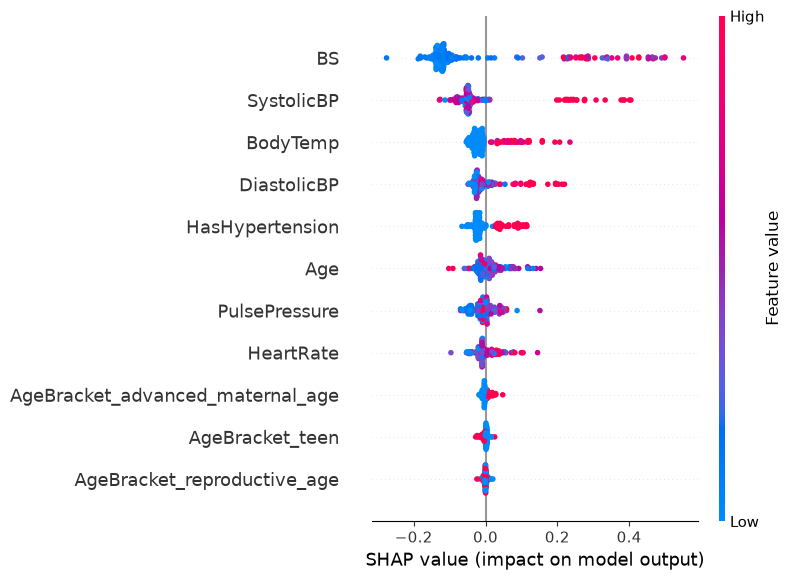

In [74]:
shap.summary_plot(shap_values[:, :, 0], X_test)

The beeswarm plot shows one dot per patient per feature. Position is the SHAP value: right
pushes toward high risk, left pushes away. Colour is the patient's actual value, red for high
and blue for low.

BS dominates, spanning roughly -0.2 to +0.55. Low values cluster left, high values spread far
right, confirming elevated blood sugar as the model's strongest high-risk indicator.

SystolicBP, DiastolicBP, BodyTemp and HasHypertension share a one-sided pattern: dots cluster at
zero with a tail extending only right. Normal readings contribute nothing, abnormal readings push
toward high risk. This mirrors how clinical thresholds work.

HasHypertension shows a clear directional effect here despite scoring near zero on permutation
importance. Both results are consistent: the signal is real but redundant, already available to
the model through the raw blood pressure columns.

Age, PulsePressure and HeartRate show weak, mixed effects. The three AgeBracket columns sit flat
at zero, the third method to confirm that binning age added nothing.

All directions are clinically plausible, supporting the conclusion that the model has learned
real signal rather than dataset artefacts.

### 9.2 Individual Patient Explanations

The beeswarm shows patterns across all patients. SHAP's other strength is explaining a single
prediction: why this particular patient was flagged, and which of their readings drove it.

This is the form of explanation that matters clinically, since a risk score is only actionable
if a clinician can see what produced it.

Patient index: 2
True label: high risk
Predicted:   high risk

Age                                    25
SystolicBP                            140
DiastolicBP                           100
BS                                   7.01
BodyTemp                             98.0
HeartRate                              80
PulsePressure                          40
HasHypertension                         1
AgeBracket_advanced_maternal_age    False
AgeBracket_reproductive_age          True
AgeBracket_teen                     False
Name: 17, dtype: object


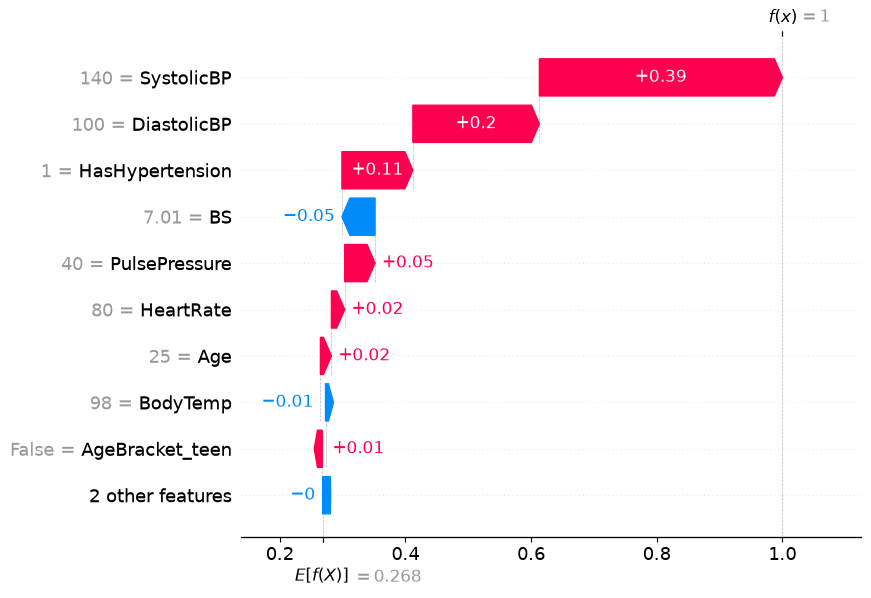

In [75]:
explanation = explainer(X_test)

# find the first patient whose true label is high risk (class 0)
i = np.where(y_test == 0)[0][0]

print(f"Patient index: {i}")
print(f"True label: {encoder.classes_[y_test[i]]}")
print(f"Predicted:   {encoder.classes_[y_pred_rf[i]]}")
print()
print(X_test.iloc[i])

# [i, :, 0] selects this patient, all features, high-risk class
shap.plots.waterfall(explanation[i, :, 0])

This patient was predicted high risk with maximum confidence: the base value of 0.268 rises to
f(x) = 1.0, meaning every tree in the forest voted high risk.

The prediction is driven almost entirely by blood pressure. SystolicBP of 140 contributes +0.39,
DiastolicBP of 100 contributes +0.20, with HasHypertension (+0.11) and PulsePressure (+0.05)
adding further. Blood sugar of 7.01 pushed slightly in the opposite direction (-0.05), and age,
heart rate and body temperature had minimal effect.

This case illustrates why global feature importance is insufficient on its own. BS is the most
important feature across the dataset, but for this patient it was near-irrelevant and mildly
protective. The high-risk classification rests on blood pressure alone.

For a clinician, this is the level of explanation required for a risk score to be actionable:
not that the model is 86% accurate, but that this specific patient was flagged because her blood
pressure reading of 140/100 crosses recognised hypertension thresholds.


### 9.3 Examining the Missed High-Risk Cases

Section 7 established that a false negative for high risk is the most clinically dangerous error
this model can make: a genuinely high-risk patient who is not flagged. The confusion matrix
shows five such cases, all predicted as mid risk.

Inspecting these individually shows whether the model failed for an understandable reason, such
as borderline readings, or whether it is missing something systematic.

In [76]:
# true label is high risk (0) but prediction was not
missed = np.where((y_test == 0) & (y_pred_rf != 0))[0]

print(f"Missed high-risk patients: {len(missed)}")
print()

# their vitals, alongside what they were predicted as
missed_df = X_test.iloc[missed].copy()
missed_df["predicted"] = [encoder.classes_[p] for p in y_pred_rf[missed]]
print(missed_df)

Missed high-risk patients: 5

     Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  PulsePressure  \
679   42         130           80  18.0      98.0         70             50   
375   60         120           80   7.8      98.0         75             40   
635   50         130           80  15.0      98.0         86             50   
181   60         120           85  15.0      98.0         60             35   
435   65         130           80  15.0      98.0         86             50   

     HasHypertension  AgeBracket_advanced_maternal_age  \
679                0                              True   
375                0                              True   
635                0                              True   
181                0                              True   
435                0                              True   

     AgeBracket_reproductive_age  AgeBracket_teen predicted  
679                        False            False  mid risk  
375                   

All five missed high-risk patients share a clear pattern. Every one has normal blood pressure
(HasHypertension = 0, systolic 120-130, diastolic 80-85), while four of the five have severely
elevated blood sugar (15.0-18.0).

This indicates a systematic limitation rather than random error. Although BS is the model's most
important feature globally, elevated blood sugar alone did not produce a high-risk prediction in
any of these cases. Section 9.2 showed blood pressure supplying almost the entire push toward a
confident high-risk classification, and these failures are consistent with that: the model
appears to depend on blood pressure elevation for high-risk confidence, leaving normotensive
hyperglycaemic patients under-flagged.

Given that a missed high-risk case is the most clinically costly error identified in section 7,
this is the model's most significant weakness. It affects 5 of 55 high-risk patients in the test
set.

A second factor is data quality. All five are in the advanced maternal age bracket, with recorded
ages of 42, 60, 50, 60 and 65. Four of these are not plausible pregnancy ages. The decision to
retain extreme age values, documented as a limitation during cleaning, has a visible cost here:
the model's worst failures cluster on records with questionable age data. With only five cases it
is not possible to determine whether the model genuinely struggles with normotensive
hyperglycaemia or whether these records are unreliable, and both explanations should be treated
as open.

True label: high risk
Predicted:  mid risk



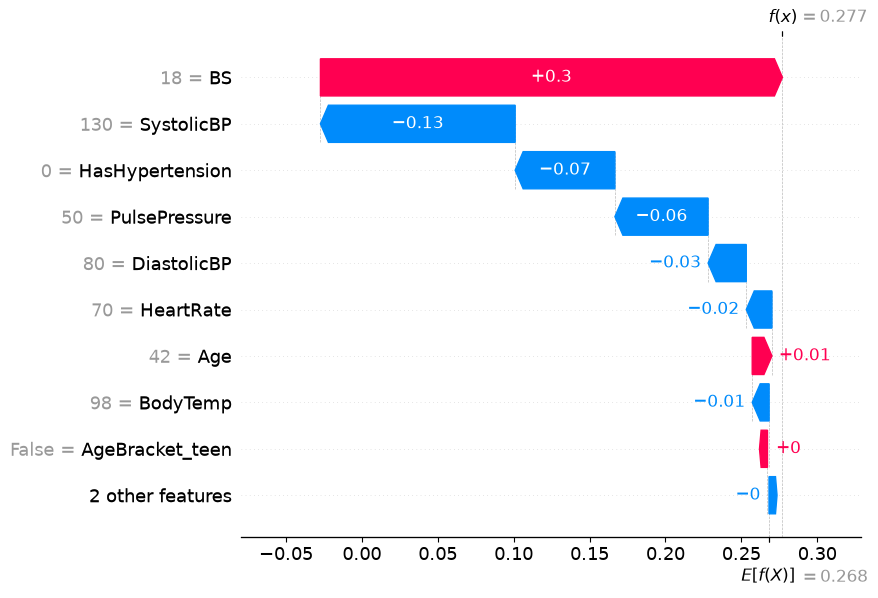

In [77]:
j = missed[0]

print(f"True label: {encoder.classes_[y_test[j]]}")
print(f"Predicted:  {encoder.classes_[y_pred_rf[j]]}")
print()

shap.plots.waterfall(explanation[j, :, 0])

The waterfall confirms the mechanism behind the missed high-risk cases. Blood sugar of 18.0
contributes +0.30, the largest single contribution seen in any explanation in this notebook, so
the model clearly registers it as a danger signal.

However, the blood pressure features push back by almost exactly the same amount: SystolicBP
(-0.13), HasHypertension (-0.07), PulsePressure (-0.06) and DiastolicBP (-0.03) total -0.29.
The prediction moves from a base value of 0.268 to just 0.277, effectively unchanged, and the
patient is classified mid risk.

The model does not ignore elevated blood sugar. It treats normal blood pressure as actively
protective rather than merely neutral, and that negative contribution is sufficient to cancel a
severely elevated glucose reading. This explains why all five missed high-risk patients were
normotensive.

Clinically this is the model's most serious weakness, since poorly controlled blood sugar is an
established pregnancy risk factor independent of blood pressure. Any deployment would need to
account for it, for example by flagging extreme BS values through a rule applied alongside the
model rather than relying on the classifier alone.

## 10. Summary

**Model selection.** Stratified 5-fold cross-validation gives Random Forest a mean macro F1 of
0.857 (sd 0.023) against 0.608 (sd 0.044) for logistic regression. The 0.249 gap matches the
original single split, confirming Random Forest as the final model. Random Forest is also the
more stable of the two.

**Feature importance.** BS, SystolicBP and Age rank highest under both impurity-based and
permutation importance. Shuffling BS costs 0.30 macro F1, reducing the model to roughly 0.56.

**Feature engineering.** PulsePressure contributed modestly. HasHypertension and the three
AgeBracket columns scored at or near zero under both methods, indicating the model derives this
information directly from the raw Age and blood pressure values. Binning and thresholding added
nothing.

**Explainability.** SHAP confirms all directional relationships are clinically plausible:
elevated blood sugar, blood pressure and body temperature all push toward high risk. Several
features are one-sided, contributing nothing at normal values and pushing toward high risk only
when abnormal.

**Key limitation.** All five missed high-risk patients are normotensive, and four have severely
elevated blood sugar (15.0-18.0). SHAP shows why: normal blood pressure produces a negative
contribution large enough to cancel a BS of 18.0, leaving the prediction unchanged from baseline.
The model treats normal blood pressure as protective rather than neutral, under-flagging
hyperglycaemic patients without hypertension. As a missed high-risk case is the most clinically
costly error, this is the model's most significant weakness.

**Secondary limitation.** All five missed cases fall in the advanced maternal age bracket with
recorded ages of 42, 60, 50, 60 and 65. Four are not plausible pregnancy ages, and the decision
to retain extreme values shows a visible cost here. With five cases it is not possible to
separate genuine model weakness from unreliable records.